Q1: Supervised Learning

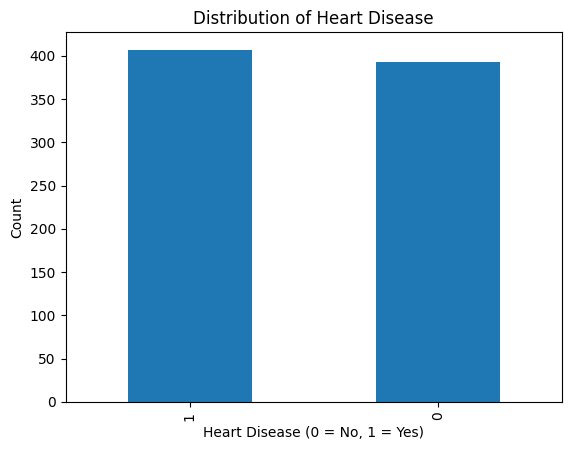

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\sriva\Downloads\data\q1_heart_disease.csv")

# 1. Data Inspection
shape = df.shape
dtypes = df.dtypes
missing = df.isnull().sum()
head = df.head()

# 2. Exploratory Data Analysis
# Target Class Distribution
plt.figure()
df['heart_disease'].value_counts().plot(kind='bar')
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()



The dataset shows a fairly balanced distribution between patients with and without heart disease.
This is beneficial because model training will not be biased toward one class.

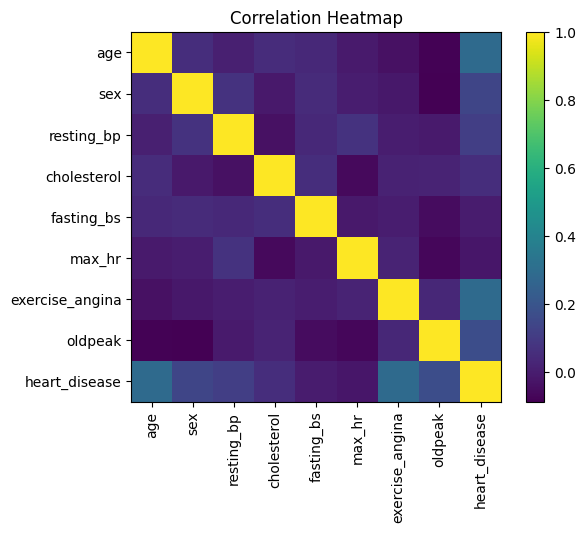

In [2]:
# Correlation Heatmap
plt.figure()
corr = df.select_dtypes(include=np.number).corr()

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

1. Some features show moderate correlation with heart_disease, such as:
 - exercise_angina
 - oldpeak
 - max_hr (negative relationship likely).
2. Most features are not highly correlated with each other, which is good because:
- It reduces multicollinearity.
- No extremely strong correlations suggest that multiple features contribute jointly to prediction.

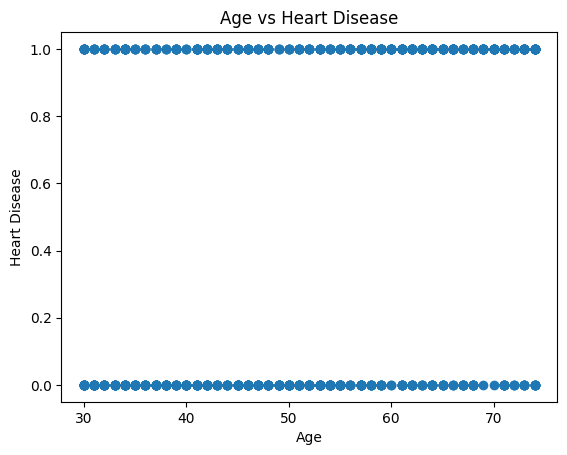

In [3]:

#Scatter plot to visualize relationship between age and heart disease
plt.figure()
plt.scatter(df['age'], df['heart_disease'])
plt.title("Age vs Heart Disease")
plt.xlabel("Age")
plt.ylabel("Heart Disease")
plt.show()

Patients with heart disease appear across a wide age range, but:
- There is a slight concentration of positive cases in higher age groups.
- However, age alone is not sufficient to predict heart disease.
- This suggests the need for multi-feature models, not single-variable decisions.

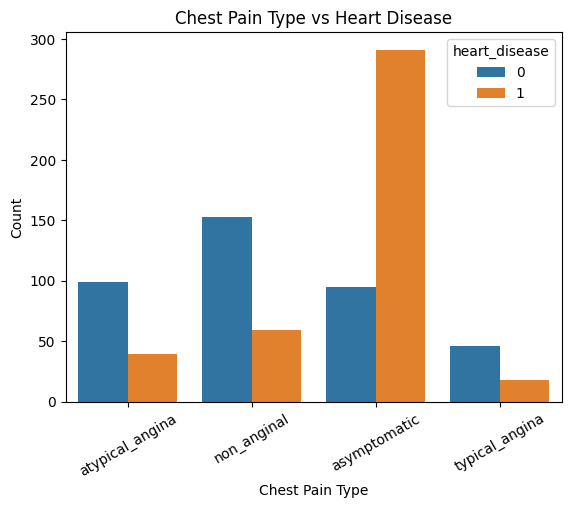

In [4]:
# Countplot to visualize relationship between chest pain type and heart disease
import seaborn as sns
plt.figure()
sns.countplot(x='chest_pain_type', hue='heart_disease', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")   
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

- Certain chest pain types (e.g., asymptomatic) are more associated with heart disease.
- Others show higher counts for non-disease cases.
- This indicates that chest pain type is an important categorical predictor

The dataset contains missing values in resting_bp and cholesterol.

Instead of dropping rows (which would reduce data size and potentially remove useful patterns), we use median imputation.

Median is preferred over mean because it is robust to outliers, which are common in medical data.

3. Data Preprocessing

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv(r"C:\Users\sriva\Downloads\data\q1_heart_disease.csv")

# 1. Handle Missing Values

df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

# 2. One-Hot Encoding

categorical_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Split Features and Target

X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']


# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# 5. Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

4. Model Training

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize Models
dt_model = DecisionTreeClassifier(random_state=42)

rf_model = RandomForestClassifier(random_state=42)

gb_model = GradientBoostingClassifier(random_state=42)

# Train Models
dt_model.fit(X_train_scaled, y_train)

rf_model.fit(X_train_scaled, y_train)

gb_model.fit(X_train_scaled, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

5. Model Evaluation
- Confusion Matrix
- Precision, Recall and F1-score on the test set

In [7]:
from sklearn.metrics import confusion_matrix, classification_report

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
    print(f"\n{name}")
    print("-" * 35)
    
    y_pred = model.predict(X_test_scaled)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    # Classification Report (Precision, Recall, F1-Score)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))



Decision Tree
-----------------------------------
Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest
-----------------------------------
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
-----------------------------------
Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
      

Decision Tree :
- Precision, Recall, and F1-score are around 0.70
- Confusion matrix shows higher false positives and false negatives.
- This indicates weaker generalization and overfitting tendency

Random Forest :
- Achieves highest Precision (~0.80) and Recall (~0.81)
- F1-score is the highest (~0.79–0.80) among all models.
- Confusion matrix shows fewer misclassifications.
- Provides a balanced performance across both classes.

Gradient Boosting :
- Performance is better than Decision Tree but slightly lower than Random Forest.
- F1-score around ~0.76–0.77
- Slightly more false negatives compared to Random Forest.

Final Conclusion :

The Random Forest model performs the best among the three models. As it has:
- Highest F1-score, which balances precision and recall.
- Better recall, meaning it correctly identifies more patients with heart disease.
- Lower false negatives, which is critical in medical diagnosis.

In healthcare applications, minimizing false negatives is crucial, and Random Forest achieves this more effectively than the other models, making it the preferred choice.

While Gradient Boosting is competitive, it slightly underperforms in recall.

The Decision Tree model performs the worst due to overfitting and higher error rates.

6. Hyperparameter Tuning (GridSearchCV)

In [8]:
# GridSearchCV on Best Model (Random Forest)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Initialize base model
rf = RandomForestClassifier(random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train_scaled, y_train)

# Best model
best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


Evaluate Tuned Model

In [9]:
# Predictions with tuned model
y_pred_tuned = best_rf.predict(X_test_scaled)

print("Confusion Matrix (Tuned Model):")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))



Confusion Matrix (Tuned Model):
[[58 21]
 [16 65]]

Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.78      0.73      0.76        79
           1       0.76      0.80      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160

